In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

OUT_DIR = r'd:\Tseng\game_eeg\winstep_predict'

df_m = pd.read_csv(f'{OUT_DIR}\\master_parietal_190d.csv')
df_a = pd.read_csv(f'{OUT_DIR}\\amateur_parietal_190d.csv')
df_p = pd.read_csv(f'{OUT_DIR}\\prof_parietal_190d.csv')

META_COLS = ['SubjectID', 'Session', 'Epoch', 'Step']
FEAT_COLS = [c for c in df_m.columns if c not in META_COLS]
SESSIONS  = ['ss01', 'ss02', 'ss03']

print('Master  sessions:', df_m['Session'].value_counts().to_dict())
print('Amateur sessions:', df_a['Session'].value_counts().to_dict())
print('Prof    sessions:', df_p['Session'].value_counts().to_dict())
print()
print('Master  Step unique:', sorted(df_m['Step'].unique()))
print('Amateur Step unique:', sorted(df_a['Step'].unique()))
print('Prof    Step unique:', sorted(df_p['Step'].unique()))

Master  sessions: {'ss02': 625, 'ss03': 623, 'ss01': 578}
Amateur sessions: {'ss02': 796, 'ss01': 773, 'ss03': 771}
Prof    sessions: {'ss01': 240, 'ss03': 240, 'ss02': 239}

Master  Step unique: [np.float64(-20.3), np.float64(-18.8), np.float64(-18.6), np.float64(-17.3), np.float64(-16.1), np.float64(-16.0), np.float64(-15.8), np.float64(-15.1), np.float64(-11.7), np.float64(-11.2), np.float64(-11.1), np.float64(-10.0), np.float64(-9.9), np.float64(-9.6), np.float64(-9.2), np.float64(-8.7), np.float64(-7.8), np.float64(-7.3), np.float64(-7.2), np.float64(-7.1), np.float64(-6.9), np.float64(-6.8), np.float64(-6.7), np.float64(-6.5), np.float64(-6.4), np.float64(-6.3), np.float64(-6.2), np.float64(-6.1), np.float64(-6.0), np.float64(-5.9), np.float64(-5.8), np.float64(-5.7), np.float64(-5.6), np.float64(-5.5), np.float64(-5.4), np.float64(-5.3), np.float64(-5.2), np.float64(-5.1), np.float64(-4.9), np.float64(-4.8), np.float64(-4.7), np.float64(-4.6), np.float64(-4.5), np.float64(-4.4),

In [6]:
results = {}

for ss in SESSIONS:
    print(f'\n====== {ss} ======')

    tr   = df_m[df_m['Session'] == ss]
    te_a = df_a[df_a['Session'] == ss]
    te_p = df_p[df_p['Session'] == ss]

    X_tr = tr[FEAT_COLS].values
    y_tr = tr['Step'].values
    print(f'  Master train: {len(X_tr)} trials  Step={y_tr.min():.4f}~{y_tr.max():.4f}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01)
    svr.fit(X_tr_s, y_tr)

    results[ss] = {}
    for name, te_df in [('amateur', te_a), ('prof', te_p)]:
        X_te   = te_df[FEAT_COLS].values
        y_te   = te_df['Step'].values
        y_pred = svr.predict(scaler.transform(X_te))

        pr, pp = pearsonr(y_te, y_pred)
        sr, sp = spearmanr(y_te, y_pred)
        mae    = mean_absolute_error(y_te, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
        r2     = r2_score(y_te, y_pred)

        results[ss][name] = {
            'y_true': y_te, 'y_pred': y_pred,
            'pearson': pr, 'pearson_p': pp,
            'spearman': sr, 'spearman_p': sp,
            'mae': mae, 'rmse': rmse, 'r2': r2,
        }
        print(f'  [{name}] N={len(y_te)}  '
              f'Pearson r={pr:.4f}(p={pp:.4f})  '
              f'Spearman r={sr:.4f}(p={sp:.4f})  '
              f'RMSE={rmse:.4f}')


====== ss01 ======
  Master train: 578 trials  Step=-7.1000~3.0000
  [amateur] N=773  Pearson r=0.0120(p=0.7400)  Spearman r=0.0248(p=0.4914)  RMSE=1.7377
  [prof] N=240  Pearson r=0.0589(p=0.3632)  Spearman r=0.0324(p=0.6180)  RMSE=1.4436

====== ss02 ======
  Master train: 625 trials  Step=-7.3000~8.3000
  [amateur] N=796  Pearson r=0.0170(p=0.6330)  Spearman r=0.0173(p=0.6268)  RMSE=4.6865
  [prof] N=239  Pearson r=0.0481(p=0.4596)  Spearman r=0.0761(p=0.2413)  RMSE=2.8817

====== ss03 ======
  Master train: 623 trials  Step=-20.3000~59.2000
  [amateur] N=771  Pearson r=-0.0353(p=0.3275)  Spearman r=-0.0057(p=0.8738)  RMSE=9.1701
  [prof] N=240  Pearson r=-0.0744(p=0.2507)  Spearman r=0.0210(p=0.7461)  RMSE=10.9836


In [7]:
print('=' * 70)
print(f'{"Session":<8} {"Group":<10} {"N":>5} {"Pearson r":>10} {"Spearman r":>11} {"RMSE":>10}')
print('-' * 70)
for ss in SESSIONS:
    for name in ['amateur', 'prof']:
        r = results[ss][name]
        sig_p = '*' if r['pearson_p'] < 0.05 else ' '
        sig_s = '*' if r['spearman_p'] < 0.05 else ' '
        print(f'{ss}  {name:<10} {len(r["y_true"]):>5} '
              f'{r["pearson"]:>9.4f}{sig_p} '
              f'{r["spearman"]:>10.4f}{sig_s} '
              f'{r["rmse"]:>10.4f}')
print('=' * 70)
print('* p < 0.05')

Session  Group          N  Pearson r  Spearman r       RMSE
----------------------------------------------------------------------
ss01  amateur      773    0.0120      0.0248      1.7377
ss01  prof         240    0.0589      0.0324      1.4436
ss02  amateur      796    0.0170      0.0173      4.6865
ss02  prof         239    0.0481      0.0761      2.8817
ss03  amateur      771   -0.0353     -0.0057      9.1701
ss03  prof         240   -0.0744      0.0210     10.9836
* p < 0.05


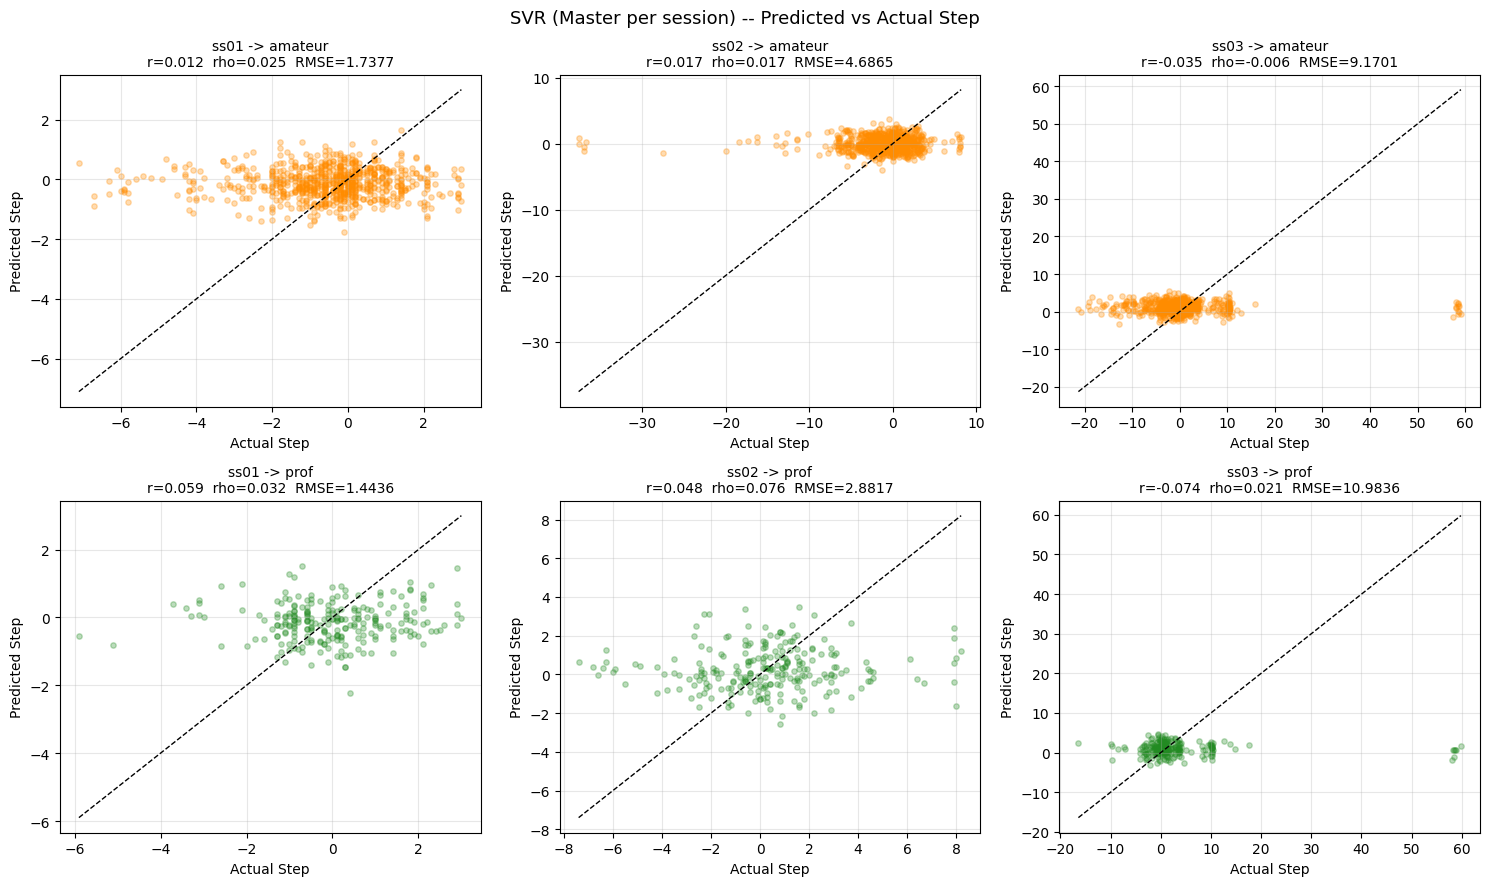

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
COLORS = {'amateur': 'darkorange', 'prof': 'forestgreen'}

for col, ss in enumerate(SESSIONS):
    for row, name in enumerate(['amateur', 'prof']):
        r = results[ss][name]
        ax = axes[row, col]
        ax.scatter(r['y_true'], r['y_pred'], alpha=0.3, s=15, color=COLORS[name])
        lo = min(r['y_true'].min(), r['y_pred'].min())
        hi = max(r['y_true'].max(), r['y_pred'].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_title(
            f'{ss} -> {name}\n'
            f'r={r["pearson"]:.3f}  rho={r["spearman"]:.3f}  RMSE={r["rmse"]:.4f}',
            fontsize=10
        )
        ax.set_xlabel('Actual Step')
        ax.set_ylabel('Predicted Step')
        ax.grid(alpha=0.3)

plt.suptitle('SVR (Master per session) -- Predicted vs Actual Step', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}\\svr_step_per_session.png', dpi=150, bbox_inches='tight')
plt.show()

SVR trained (all sessions, N=1826)


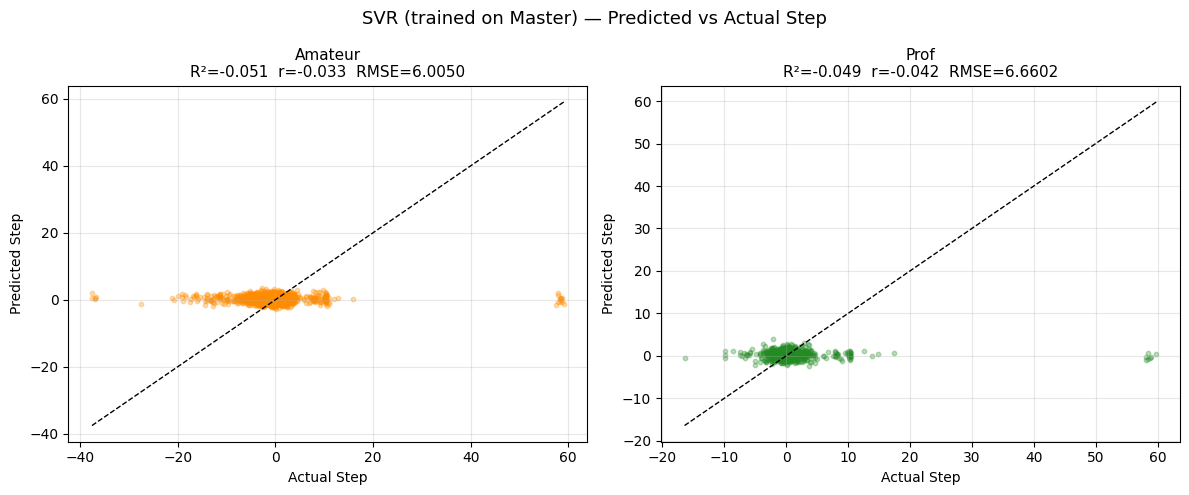

In [5]:
# All sessions combined: train on Master, predict Amateur & Prof
scaler_all = StandardScaler()
X_tr_all = scaler_all.fit_transform(df_m[FEAT_COLS].values)
y_tr_all  = df_m['Step'].values

svr_all = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01)
svr_all.fit(X_tr_all, y_tr_all)
print('SVR trained (all sessions, N=%d)' % len(y_tr_all))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
COLORS_ALL = {'Amateur': 'darkorange', 'Prof': 'forestgreen'}

for ax, (name, df_te) in zip(axes, [('Amateur', df_a), ('Prof', df_p)]):
    y_te   = df_te['Step'].values
    y_pred = svr_all.predict(scaler_all.transform(df_te[FEAT_COLS].values))
    r2    = r2_score(y_te, y_pred)
    pr, _ = pearsonr(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    ax.scatter(y_te, y_pred, alpha=0.3, s=10, color=COLORS_ALL[name])
    lo = min(y_te.min(), y_pred.min())
    hi = max(y_te.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(f'{name}\nR²={r2:.3f}  r={pr:.3f}  RMSE={rmse:.4f}', fontsize=11)
    ax.set_xlabel('Actual Step')
    ax.set_ylabel('Predicted Step')
    ax.grid(alpha=0.3)

plt.suptitle('SVR (trained on Master) — Predicted vs Actual Step', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}\\svr_step_overall.png', dpi=150, bbox_inches='tight')
plt.show()